# Dictionary learning with nonconvex Frank-Wolfe

## Problem

We want to solve

$$\min\limits_{D\in\mathbb{R}^{n\times p}, Z\in\mathbb{R}^{p\times m}} \frac{1}{2}\|X-DZ\|_2^2 +\iota_{\mathcal{C}_1}(Z) + \iota_{\mathcal{C}_*}(D)$$

where $\mathcal{C}_1$ is the $\ell^1$ ball in some sense (over columns, since the columns of $D$ are the dictionary elements) and $\mathcal{C}_*$ is the nuclear norm ball with some radius.

The constraints in this problem are chosen to induce sparsity on the code matrix $Z$ and induce low-rankedness on the dictionary matrix $D$. Maybe it makes more sense to induce full-rankedness on $D$?... Low rank $D$ means that some atoms are redundant right?.

Ideas for $D$ constraints:

* Full rank $D$
* Low rank $D$
* Low rank $D$ and unit columns
* Full rank $D$ and unit columns
* Unit columns only

Ideas for $Z$ constraints:

* Sparse entire $Z$
* Sparse columns (which represents sparse combinations of columns of $D$)
* Low rank (which represents that many things have similar encodings)
* Simplex constraint on columns (which means each code represents a convex combination of columns of $D$)
* Nonnegativity (which when combined with sparsity is just a scaled version of the simplex)


In [1]:
from scipy.sparse.linalg import svds
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np

The SCAD regularizer is given by
$$R(x,\lambda, a) = \begin{cases} \lambda |x| & \mathrm{ if }|x|\leq \lambda\\ \frac{2a\lambda|x|-x^2-\lambda^2}{2(a-1)} & \mathrm{ if }\lambda<|x|\leq a\lambda\\ \frac{\lambda^2(a+1)}{2} & \mathrm{ else.}\end{cases}$$

In [18]:
def scad(a, lam, x):
    """
    SCAD regularizer
    """
    abx = np.abs(x)
    condition1 = abx <= lam
    condition2 = np.logical_and(lam < abx, abx <= a * lam)
    result = np.zeros_like(x)
    result[condition1] = lam * abx[condition1]
    result[condition2] = (2 * a * lam * abx[condition2] - (x[condition2] ** 2) - (lam ** 2)) / (2 * (a - 1))
    result[~(condition1 | condition2)] = ((lam ** 2) * (a + 1)) / 2
    return result

def scad_grad(a, lam, x):
    """
    Gradient of SCAD regularizer
    """
    abx = np.abs(x)
    signx = np.sign(x)
    condition1 = abx <= lam
    condition2 = np.logical_and(lam < abx, abx <= a * lam)
    result = np.zeros_like(x)
    result[condition1] = lam * signx[condition1]
    result[condition2] = (2 * a * lam * signx[condition2] - (2*x[condition2])) / (2 * (a - 1))
    return result

def scad_prox(a, lam, x):
    """
    Vectorized prox of the SCAD regularizer (a must be >=2)
    """
    abx = np.abs(x)
    result = np.zeros_like(x)
    
    condition1 = abx <= 2 * lam
    condition2 = np.logical_and(2 * lam < abx, abx <= a * lam)
    
    result[condition1] = np.sign(x[condition1]) * np.maximum(abx[condition1] - lam, 0)
    result[condition2] = ((a - 1) * x[condition2] - np.sign(x[condition2]) * a * lam) / (a - 2)
    result[~(condition1 | condition2)] = x[~(condition1 | condition2)]
    
    return result

In [16]:

def sigmoid(x):
    return 1. / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return sigmoid(x) * (1 - sigmoid(x))

def scad_subdiff(x):
    result = np.zeros_like(x)
    inner_mask = np.abs(x) < 1
    result[inner_mask] = np.sign(x[inner_mask])
    middle_mask_pos = (x > 1) & (x < 2)
    result[middle_mask_pos] = 2 - x[middle_mask_pos]
    middle_mask_neg = (x < -1) & (x > -2)
    result[middle_mask_neg] = -x[middle_mask_neg] - 2
    return result

def graph(x):
    return scad_subdiff(x) + sigmoid_derivative(x)

In [9]:
def dist(x):
    return np.piecewise(x, [
        x > 2,
        (x > 1) & (x <= 2),
        (x > 0) & (x <= 1),
        (x > -3) & (x <= 0),
        x <= -3
    ], [
        lambda x: 2 - x,
        lambda x: 0,
        lambda x: 1 - x,
        lambda x: np.sqrt(x**2 + (1 - x)**2),
        lambda x: 2 - x
    ])

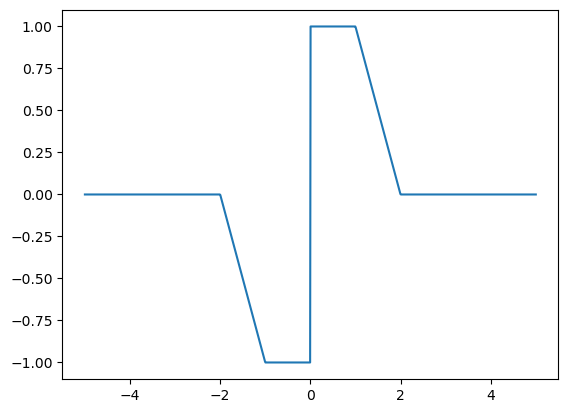

In [18]:
xmesh = np.linspace(-5,5,1000)
#vals = scad_grad(2.1, 1, xmesh)
#moreau = (xmesh - scad_prox(2.1, 1, xmesh))/4
graphs = scad_subdiff(xmesh)
plt.plot(xmesh, graphs)
# plt.plot(xmesh, moreau)
plt.show()

To maintain consistency with previous code, we will rename $U:=D$ and $V:=Z$

In [80]:
def objective(U, V, X):
    """
    Objective function: 1/2 * ||UV - X||_2^2
    """
    return 0.5 * np.linalg.norm(U @ V - X, 'fro')**2

def grad_U(U, V, X):
    """
    Closed-form gradient of the objective with respect to U
    """
    return (U @ V - X) @ V.T

def grad_V(U, V, X):
    """
    Closed-form gradient of the objective with respect to V
    """
    return U.T @ (U @ V - X)

def proj_nonneg(U):
    """
    Projection onto the nonnegative orthant
    """
    return np.maximum(U, 0)

def moreau_grad(U):
    """
    Gradient of the square distance function to the nonnegative orthant
    """
    return U - proj_nonneg(U)

def soft_thresh(U, beta):
    return np.sign(U) * np.maximum(np.abs(U) - beta, 0)

def lmo(gradient, radius, constraint_set):
    if constraint_set == "l1_ball":
        # Implement LMO for L1 ball
        # Handle both vector and matrix inputs
        index_flat = np.argmax(np.abs(gradient))
        index_multi = np.unravel_index(index_flat, gradient.shape)
        s = np.zeros_like(gradient)
        s[index_multi] = np.sign(gradient[index_multi])
        s = -radius * s
        return s
    elif constraint_set == "nuclear_norm_ball":
        # Implement LMO for nuclear norm ball
        # Assume gradient is a matrix
        u, _, vt = svds(gradient, k=1)
        s = -radius * np.outer(u, vt)
        return s
    elif constraint_set == "l2_ball":
        # Implement LMO for L2 ball
        # Handle both vector and matrix inputs
        gradient_norm = np.linalg.norm(gradient)
        if gradient_norm > 0:
            s = -radius * gradient / gradient_norm
        else:
            # Handle the case when the gradient is zero
            s = np.zeros_like(gradient)
        return s
    elif constraint_set == "l1_ball_columns":
        # Implement LMO for the the L1 ball on each column
        col_indices = np.argmax(np.abs(gradient), axis=0)
        s = np.zeros_like(gradient)
        signs = np.sign(gradient[col_indices, np.arange(gradient.shape[1])])
        s[indices, np.arange(gradient.shape[1])] = signs
        s = -radius * s
        return s
    else:
        raise ValueError(f"Unsupported constraint set: {constraint_set}")

def frank_wolfe(U, V, U_rad, V_rad, U_constraint, V_constraint, n_steps, X):
    # initialize arrays to store results
    func_vals = np.zeros(n_steps)
    gaps = np.zeros(n_steps)
    feasibility = np.zeros(n_steps)
    
    for i in tqdm(range(n_steps), desc="Frank-Wolfe Progress"):
        beta = 1.0 / (i + 1)
        step_size = 1.0 / np.sqrt((i + 2))
        
        U_grad = grad_U(U, V, X)
        V_grad = grad_V(U, V, X)
        
        U_moreau_grad = (1./beta) * moreau_grad(U)
        V_moreau_grad = (1./beta) * moreau_grad(V)
        
        U_grad += U_moreau_grad
        V_grad += V_moreau_grad
        
        U_direction = lmo(U_grad, U_rad, U_constraint)
        V_direction = lmo(V_grad, V_rad, V_constraint)
        
        U_new = (1 - step_size) * U + step_size * U_direction
        V_new = (1 - step_size) * V + step_size * V_direction
        
        U, V = U_new, V_new
        
        # Compute and store results
        func_val = objective(U_new, V_new, X)
        func_vals[i] = func_val
        
        feas = beta * (np.linalg.norm(U_moreau_grad.flatten())**2 + np.linalg.norm(V_moreau_grad.flatten())**2)
        feasibility[i] = feas
        
        U_gap = np.sum(U_grad * (U - U_direction))
        V_gap = np.sum(V_grad * (V - V_direction))
        gap = U_gap + V_gap
        gaps[i] = gap
    
    return U, V, func_vals, feasibility, gaps

In [81]:
# Generate random data
n = X.shape[0]
p = X.shape[1]
# m is the number of atoms in the dictionary
m = 1000
U = np.random.rand(n, m)
V = np.random.rand(m, p)

# Set constraint radii
U_rad = 100.0
V_rad = m * p / 5

# Number of iterations
n_steps = 100

# Run the algorithm
U, V, func_vals, feasibility, gaps = frank_wolfe(U, V, U_rad, V_rad, 'nuclear_norm_ball', 'l1_ball', n_steps, X)

Frank-Wolfe Progress: 100%|██████████| 100/100 [08:42<00:00,  5.22s/it]


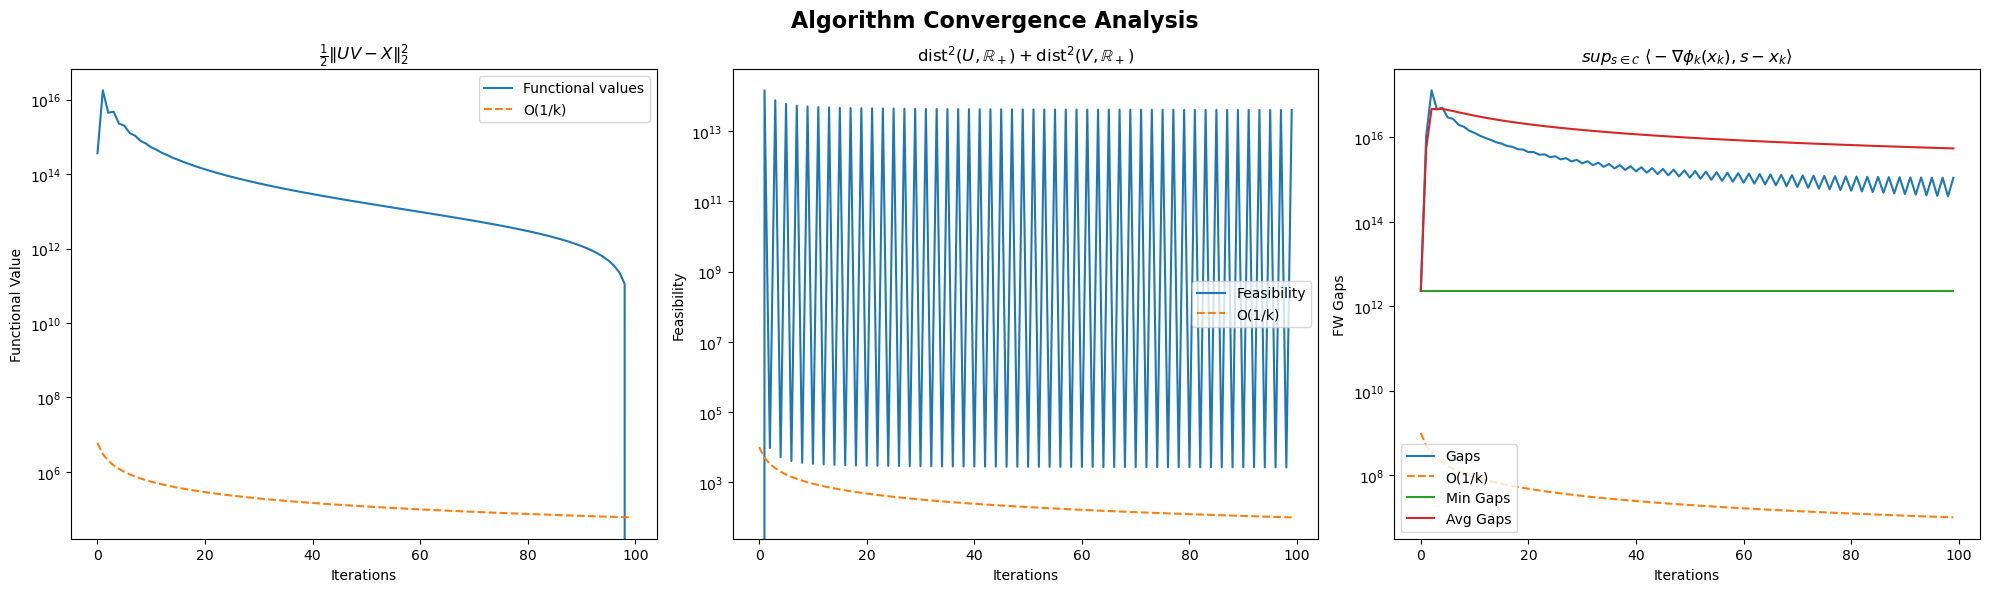

In [82]:
min_gaps = np.zeros(n_steps)
avg_gaps = np.zeros(n_steps)
for i in range(n_steps):
    min_gap = np.min(gaps[:i+1])
    min_gaps[i] = min_gap
    avg_gap = np.mean(gaps[:i+1])
    avg_gaps[i] = avg_gap

fig, axs = plt.subplots(1, 3, figsize=(20, 6))  # Create a figure with 3 subplots side by side

# Plot functional values
axs[0].semilogy(range(n_steps), func_vals-func_vals[-1], label=r'Functional values')
axs[0].semilogy(range(0, n_steps), 6e6 / np.array(range(1, n_steps + 1)), '--', label='O(1/k)')
axs[0].set_title(r'$\frac{1}{2}\|UV-X\|_2^2$')
axs[0].set_xlabel('Iterations')
axs[0].set_ylabel('Functional Value')
axs[0].legend()

# Plot feasibility
axs[1].semilogy(range(n_steps), feasibility, label='Feasibility')
axs[1].semilogy(range(0, n_steps), 1e4 / np.array(range(1, n_steps + 1)), '--', label='O(1/k)')
axs[1].set_title(r'$\mathrm{dist}^2(U,\mathbb{R}_+) + \mathrm{dist}^2(V,\mathbb{R}_+)$')
axs[1].set_xlabel('Iterations')
axs[1].set_ylabel('Feasibility')
axs[1].legend()

# Plot gaps
axs[2].semilogy(range(n_steps), gaps, label='Gaps')
axs[2].semilogy(range(0, n_steps), 1e9 / np.array(range(1, n_steps + 1)), '--', label='O(1/k)')
axs[2].semilogy(range(n_steps), min_gaps, label='Min Gaps')
axs[2].semilogy(range(n_steps), avg_gaps, label='Avg Gaps')
axs[2].set_title(r'$sup_{s\in \mathcal{C}}\ \left\langle -\nabla \phi_k(x_k), s-x_k\right\rangle$')
axs[2].set_xlabel('Iterations')
axs[2].set_ylabel('FW Gaps')
axs[2].legend()

# Adjust spacing and alignment
plt.tight_layout()
fig.subplots_adjust(top=0.88)  # Adjust the top spacing

# Add a common title for the entire figure
fig.suptitle('Algorithm Convergence Analysis', fontsize=16, fontweight='bold')

plt.show()